In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pde_solver_2d import PDE, PDESystem

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

def gaussian(x, mu=None, sigma=0.3):
    if mu is None: mu = L / 3
    return np.exp(-((x - mu)**2) / sigma**2)
# Shared 2D grid
nx, ny = 32, 32
x = np.linspace(0, 1, nx2)
y = np.linspace(0, 1, ny2)

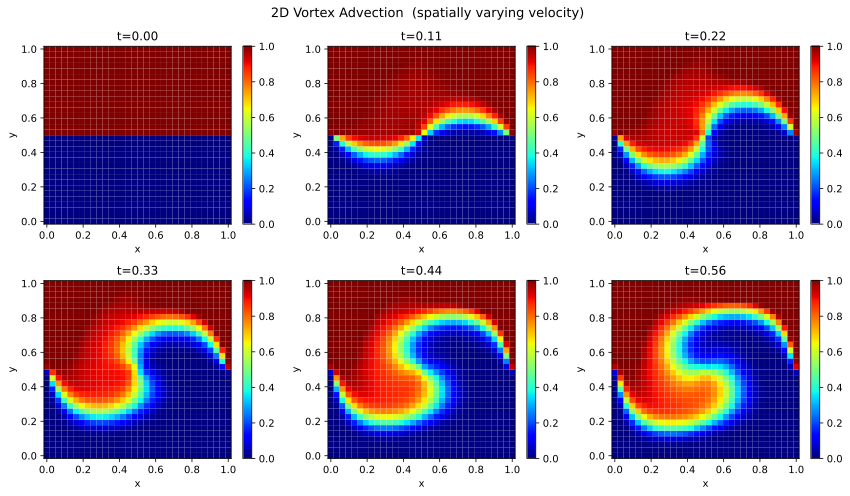

In [10]:
"""
Streamfunction: psi = psi0 * sin^2(pi x) * sin^2(pi y)
u = dpsi/dy, v = -dpsi/dx
"""
k = 1e-4
psi0 = 1.0
pi = 1.0*np.pi
# u =  psi0* np.sin(pi*X)**2 * np.sin(2*pi*Y)
# v = - psi0*np.sin(2*pi*X) * np.sin(pi*Y)**2

eq = PDE('T', x=x, y=y)
eq.add_advection(
    velocity_x=lambda x, y, T: psi0* np.sin(pi*x)**2 * np.sin(2*pi*y),
    velocity_y=lambda x, y, T:  - psi0*np.sin(2*pi*x) * np.sin(pi*y)**2
)

eq.add_diffusion(diffusivity=k)
eq.set_bc(side='left',   kind='neumann', value=0.0)
eq.set_bc(side='right',  kind='neumann', value=0.0)
eq.set_bc(side='bottom', kind='neumann', value=0.0)
eq.set_bc(side='top',    kind='neumann', value=0.0)

U0 = np.zeros((nx, ny))
U0[:, nx//2:] = 1.0
eq.set_ic(U0)

tf = 1
teval = np.linspace(0, tf, 10)
sol = PDESystem([eq]).solve(
    t_span=(0, tf),
    method='RK45', rtol=1e-4, atol=1e-6,
    t_eval=teval)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
fig.suptitle('2D Vortex Advection  (spatially varying velocity)', fontsize=13)
vmax = sol.T[:, :, 0].max()
for ax, ti, lab in zip(axes.ravel(), range(6),
                        [f't={teval[i]:.2f}' for i in range(6)]):
    im = ax.pcolormesh(x2, y2, sol.T[:, :, ti].T,
                       shading='auto', cmap='jet', vmin=0, vmax=vmax)
    ax.set_title(lab); ax.set_xlabel('x'); ax.set_ylabel('y')
    plt.colorbar(im, ax=ax)
plt.tight_layout()